
Dataset Preview

    Department  Study_Hours  Attendance  Library_Usage  Internet_Usage  \
0           IT            1          73             27               7   
1  Electronics            5          85             14               7   
2           AI            7          63              5               7   
3  Electronics           10          84              7               3   
4  Electronics           10          84             26               2   

   Teacher_Experience  Lab_Utilization  Classroom_Utilization  Final_Score  \
0                   6               80                     62    62.274066   
1                  18               69                     60    91.152099   
2                  13               73                     95    85.340402   
3                   3               74                     68   100.000000   
4                  24               85                     60   100.000000   

  Grade  
0     D  
1     A  
2     B  
3     A  
4     A  

Average

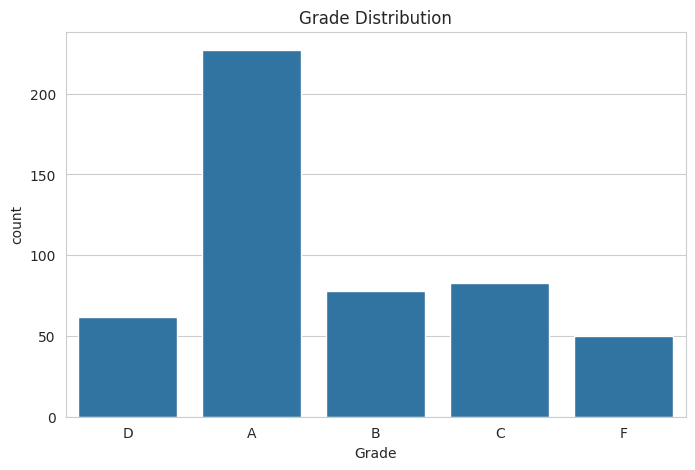

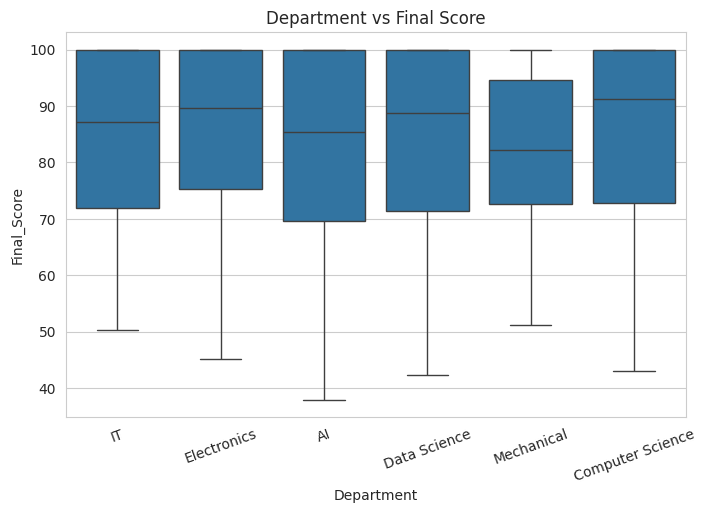

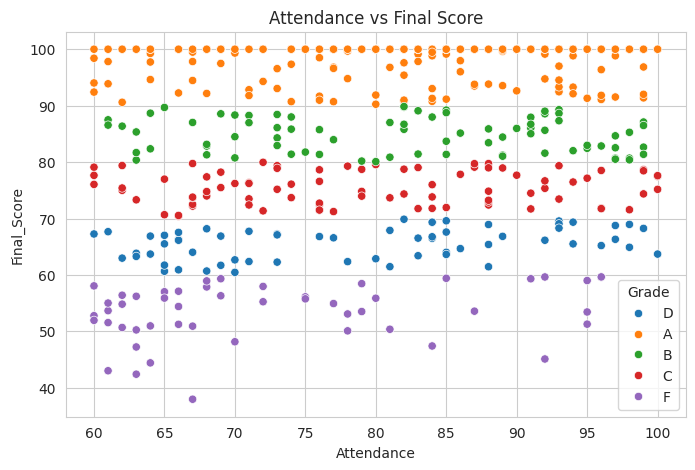

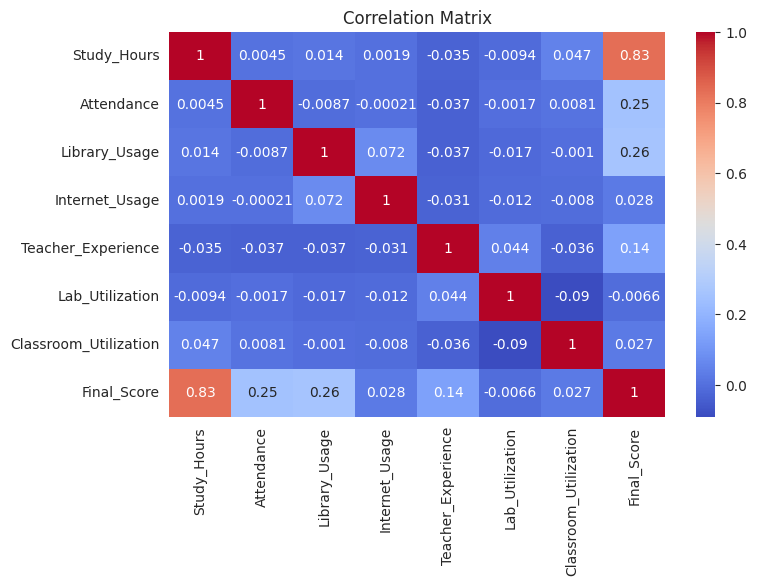


Resource Utilization

                  Lab_Utilization  Classroom_Utilization  Library_Usage
Department                                                             
AI                      73.350649              76.506494      14.974026
Computer Science        73.544444              76.800000      15.544444
Data Science            75.093333              73.066667      14.600000
Electronics             76.786667              73.200000      14.186667
IT                      73.092784              76.783505      14.690722
Mechanical              79.627907              75.546512      16.011628


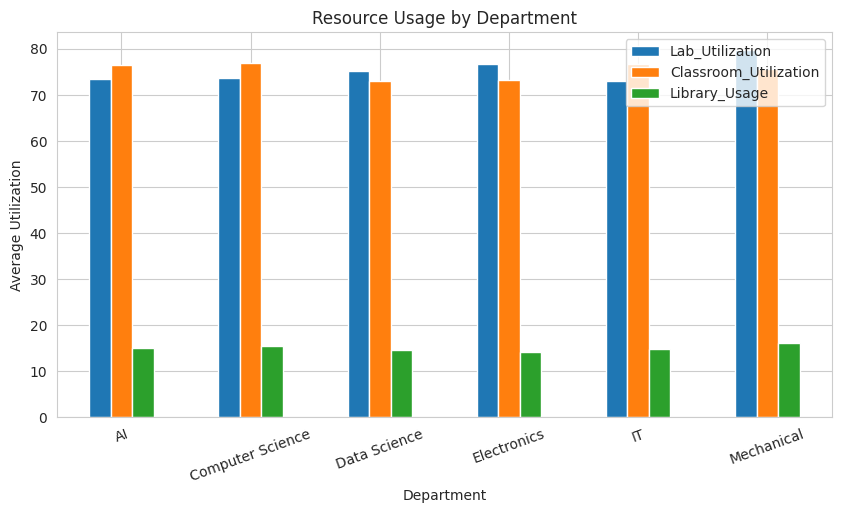


CSV exported successfully!
File Name: education_dashboard_data.csv

========== DASHBOARD KPIs ==========
Total Students : 500
Average Score : 83.88
Highest Score : 100.0
Lowest Score : 37.98
Average Attendance : 80.68
Prediction Accuracy : 90.25 %


In [1]:
# ============================================================
# EDUCATIONAL PERFORMANCE & RESOURCE ALLOCATION DASHBOARD
# Single Google Colab Script
# ============================================================

# Install Libraries
!pip -q install pandas numpy matplotlib seaborn plotly scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

np.random.seed(42)

# ============================================================
# Generate Educational Dataset
# ============================================================

students = 500

departments = np.random.choice(
    ["Computer Science","Data Science","AI","IT","Electronics","Mechanical"],
    students)

study_hours = np.random.randint(1,11,students)

attendance = np.random.randint(60,101,students)

library_usage = np.random.randint(0,31,students)

internet_usage = np.random.randint(1,8,students)

teacher_experience = np.random.randint(1,26,students)

lab_utilization = np.random.randint(50,101,students)

classroom_utilization = np.random.randint(50,101,students)

score = (
    study_hours*6 +
    attendance*0.45 +
    library_usage*0.7 +
    teacher_experience*0.6 +
    np.random.normal(0,5,students)
)

score = np.clip(score,35,100)

grades = []

for s in score:
    if s>=90:
        grades.append("A")
    elif s>=80:
        grades.append("B")
    elif s>=70:
        grades.append("C")
    elif s>=60:
        grades.append("D")
    else:
        grades.append("F")

df = pd.DataFrame({
    "Department":departments,
    "Study_Hours":study_hours,
    "Attendance":attendance,
    "Library_Usage":library_usage,
    "Internet_Usage":internet_usage,
    "Teacher_Experience":teacher_experience,
    "Lab_Utilization":lab_utilization,
    "Classroom_Utilization":classroom_utilization,
    "Final_Score":score,
    "Grade":grades
})

# ============================================================
# Display Dataset
# ============================================================

print("\nDataset Preview\n")
print(df.head())

# ============================================================
# Student Performance Metrics
# ============================================================

print("\nAverage Score:",round(df["Final_Score"].mean(),2))
print("Average Attendance:",round(df["Attendance"].mean(),2))
print("Average Study Hours:",round(df["Study_Hours"].mean(),2))

# ============================================================
# Machine Learning Prediction
# ============================================================

X = df[[
    "Study_Hours",
    "Attendance",
    "Library_Usage",
    "Internet_Usage",
    "Teacher_Experience",
    "Lab_Utilization",
    "Classroom_Utilization"
]]

y = df["Final_Score"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

model = RandomForestRegressor(n_estimators=150,random_state=42)

model.fit(X_train,y_train)

prediction=model.predict(X_test)

accuracy=r2_score(y_test,prediction)

print("\nPrediction Accuracy (R2 Score):",round(accuracy,3))

# ============================================================
# Feature Importance
# ============================================================

importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
}).sort_values("Importance",ascending=False)

print("\nFeature Importance\n")
print(importance)

# ============================================================
# Visualizations
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x="Grade",data=df)
plt.title("Grade Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Department",y="Final_Score",data=df)
plt.xticks(rotation=20)
plt.title("Department vs Final Score")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Attendance",
    y="Final_Score",
    hue="Grade",
    data=df)
plt.title("Attendance vs Final Score")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ============================================================
# Plotly Interactive Dashboard
# ============================================================

fig1 = px.bar(
    df.groupby("Department")["Final_Score"].mean().reset_index(),
    x="Department",
    y="Final_Score",
    color="Department",
    title="Average Score by Department"
)
fig1.show()

fig2 = px.pie(
    df,
    names="Grade",
    title="Grade Distribution"
)
fig2.show()

fig3 = px.scatter(
    df,
    x="Attendance",
    y="Final_Score",
    color="Department",
    size="Study_Hours",
    title="Attendance vs Performance"
)
fig3.show()

fig4 = px.bar(
    importance,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Factors Affecting Student Performance"
)
fig4.show()

# ============================================================
# Resource Allocation Analysis
# ============================================================

resource = df.groupby("Department")[[
    "Lab_Utilization",
    "Classroom_Utilization",
    "Library_Usage"
]].mean()

print("\nResource Utilization\n")
print(resource)

resource.plot(kind="bar",figsize=(10,5))
plt.title("Resource Usage by Department")
plt.ylabel("Average Utilization")
plt.xticks(rotation=20)
plt.show()

# ============================================================
# Export CSV for Power BI
# ============================================================

df.to_csv("education_dashboard_data.csv",index=False)

print("\nCSV exported successfully!")
print("File Name: education_dashboard_data.csv")

# ============================================================
# Dashboard KPIs
# ============================================================

print("\n========== DASHBOARD KPIs ==========")
print("Total Students :",len(df))
print("Average Score :",round(df["Final_Score"].mean(),2))
print("Highest Score :",round(df["Final_Score"].max(),2))
print("Lowest Score :",round(df["Final_Score"].min(),2))
print("Average Attendance :",round(df["Attendance"].mean(),2))
print("Prediction Accuracy :",round(accuracy*100,2),"%")
print("===================================")